#Plant disease prediction

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import random
import numpy as np
import pandas as pd
import cv2
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [5]:
!pip install lime shap pdpbox

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 151.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 11.8 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=5a52ced6f7d8e3b81ce4a5c01eb4f80b3c964594c2d1ffd3137316c9b5571e10
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [6]:
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
from pdpbox import pdp


In [7]:
import os
import random
import numpy as np
import pandas as pd
import cv2
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


data_dir = '/content/drive/MyDrive/archive (2)'

train_dir = os.path.join(data_dir, 'Train/Train')
test_dir = os.path.join(data_dir, 'Test/Test')
val_dir = os.path.join(data_dir, 'Validation/Validation')

def load_dataset(base_dir):
    image_paths, labels = [], []
    for label in os.listdir(base_dir):
        label_path = os.path.join(base_dir, label)
        if os.path.isdir(label_path):
            for file in os.listdir(label_path):
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    image_paths.append(os.path.join(label_path, file))
                    labels.append(label)
    return pd.DataFrame({'image_path': image_paths, 'label': labels})

train_df = load_dataset(train_dir)
test_df = load_dataset(test_dir)
val_df = load_dataset(val_dir)

print("Dataset Loaded Successfully!")
print(f"Train: {train_df.shape}, Test: {test_df.shape}, Validation: {val_df.shape}")

Dataset Loaded Successfully!
Train: (1333, 2), Test: (152, 2), Validation: (63, 2)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1333 entries, 0 to 1332
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  1333 non-null   object
 1   label       1333 non-null   object
dtypes: object(2)
memory usage: 21.0+ KB
None

Missing Values:
 image_path    0
label         0
dtype: int64

Number of Classes: 3
label
Healthy    469
Rust       434
Powdery    430
Name: count, dtype: int64


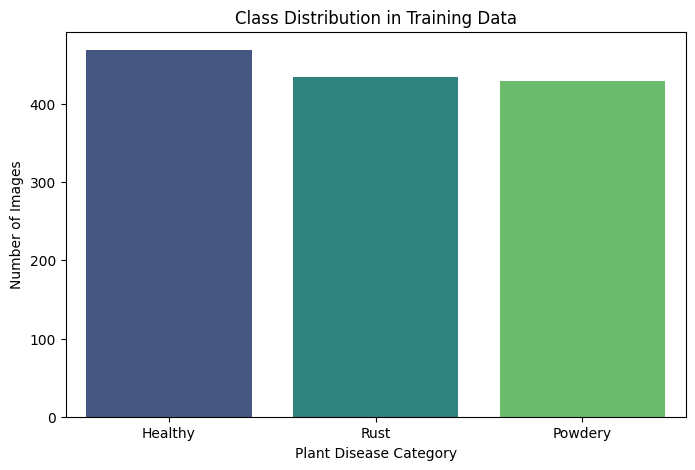

In [8]:
print(train_df.info())
print("\nMissing Values:\n", train_df.isnull().sum())
print("\nNumber of Classes:", train_df['label'].nunique())
print(train_df['label'].value_counts())
plt.figure(figsize=(8,5))
sns.countplot(x='label', data=train_df, order=train_df['label'].value_counts().index, palette='viridis')
plt.title('Class Distribution in Training Data')
plt.xlabel('Plant Disease Category')
plt.ylabel('Number of Images')
plt.show()


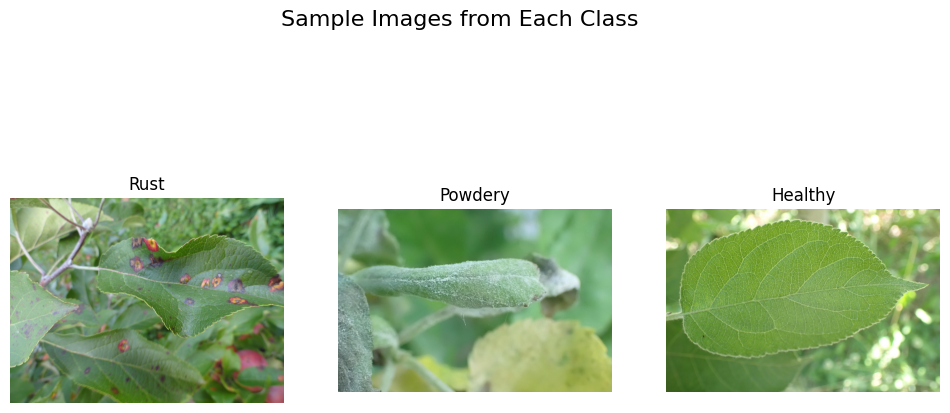

In [9]:
plt.figure(figsize=(12, 6))
classes = train_df['label'].unique()
for i, cls in enumerate(classes):
    sample_path = random.choice(train_df[train_df['label'] == cls]['image_path'].values)
    img = Image.open(sample_path)
    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.suptitle("Sample Images from Each Class", fontsize=16)
plt.show()


100%|██████████| 300/300 [02:13<00:00,  2.26it/s]


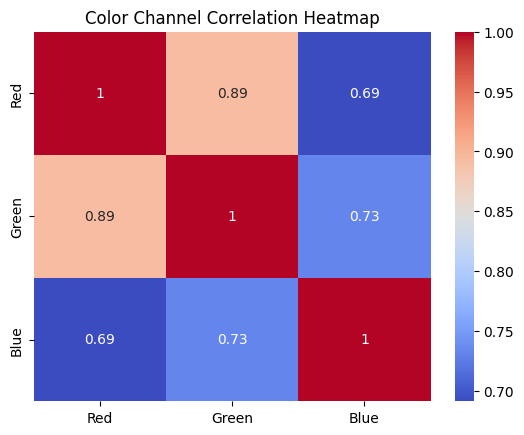

In [10]:
features = []
for path in tqdm(train_df['image_path'][:300]):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (64, 64))
    mean_color = img.mean(axis=(0,1))
    features.append(mean_color)

feature_df = pd.DataFrame(features, columns=['Red', 'Green', 'Blue'])
sns.heatmap(feature_df.corr(), annot=True, cmap='coolwarm')
plt.title("Color Channel Correlation Heatmap")
plt.show()


In [11]:


import tensorflow as tf

BATCH_SIZE = 32
IMG_SIZE = (128, 128)
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)



Found 1333 files belonging to 3 classes.
Found 63 files belonging to 3 classes.
Found 152 files belonging to 3 classes.


In [13]:
def extract_rgb_features(df, img_size=(64,64)):
    features = []
    for path in tqdm(df['image_path']):
        img = Image.open(path).convert('RGB')
        img = img.resize(img_size)
        img_array = np.array(img)
        mean_rgb = img_array.mean(axis=(0,1))
        features.append(mean_rgb)
    return np.array(features)


X_train_rf = extract_rgb_features(train_df)
X_test_rf = extract_rgb_features(test_df)
X_val_rf = extract_rgb_features(val_df)

le = LabelEncoder()
y_train_rf = le.fit_transform(train_df['label'])
y_test_rf = le.transform(test_df['label'])
y_val_rf = le.transform(val_df['label'])


scaler = StandardScaler()
X_train_rf = scaler.fit_transform(X_train_rf)
X_test_rf = scaler.transform(X_test_rf)
X_val_rf = scaler.transform(X_val_rf)

print("Random Forest Preprocessing Done!")

100%|██████████| 63/63 [00:07<00:00,  8.92it/s]

Random Forest Preprocessing Done!


Train Accuracy: 1.0000
Validation Accuracy: 0.6032
Test Accuracy: 0.6382

Classification Report (Test Data):
              precision    recall  f1-score   support

     Healthy       0.57      0.67      0.62        52
     Powdery       0.69      0.62      0.65        50
        Rust       0.67      0.62      0.65        50

    accuracy                           0.64       152
   macro avg       0.65      0.64      0.64       152
weighted avg       0.64      0.64      0.64       152



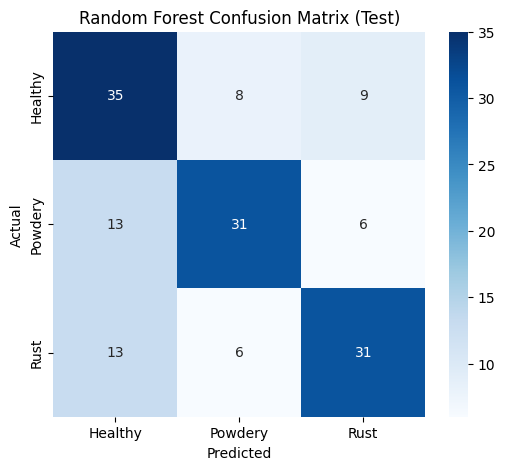

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train_rf, y_train_rf)

y_pred_train = rf_model.predict(X_train_rf)
y_pred_val   = rf_model.predict(X_val_rf)
y_pred_test  = rf_model.predict(X_test_rf)

train_acc = accuracy_score(y_train_rf, y_pred_train)
val_acc   = accuracy_score(y_val_rf, y_pred_val)
test_acc  = accuracy_score(y_test_rf, y_pred_test)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

print("\nClassification Report (Test Data):")
print(classification_report(y_test_rf, y_pred_test, target_names=le.classes_))
cm = confusion_matrix(y_test_rf, y_pred_test)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix (Test)')
plt.show()

In [15]:

from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
gb_model = GradientBoostingClassifier(n_estimators=200, random_state=42)
xgb_model = XGBClassifier(n_estimators=200, random_state=42, eval_metric='mlogloss')

models = {
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model
}

for name, model in models.items():
    print(f"\n {name}...")
    model.fit(X_train_rf, y_train_rf)
    y_pred = model.predict(X_test_rf)

    acc = accuracy_score(y_test_rf, y_pred)
    f1 = f1_score(y_test_rf, y_pred, average='weighted')

    print(f" {name} Accuracy: {acc*100:.2f}%")
    print(f"F1-Score: {f1*100:.2f}%")
    print("Confusion Matrix:\n", confusion_matrix(y_test_rf, y_pred))
    print("Classification Report:\n", classification_report(y_test_rf, y_pred))



 Gradient Boosting...
 Gradient Boosting Accuracy: 59.21%
F1-Score: 59.22%
Confusion Matrix:
 [[32  8 12]
 [15 31  4]
 [12 11 27]]
Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.62      0.58        52
           1       0.62      0.62      0.62        50
           2       0.63      0.54      0.58        50

    accuracy                           0.59       152
   macro avg       0.60      0.59      0.59       152
weighted avg       0.60      0.59      0.59       152


 XGBoost...
 XGBoost Accuracy: 57.89%
F1-Score: 57.94%
Confusion Matrix:
 [[28 12 12]
 [12 31  7]
 [14  7 29]]
Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.54      0.53        52
           1       0.62      0.62      0.62        50
           2       0.60      0.58      0.59        50

    accuracy                           0.58       152
   macro avg       0.58      0.58      0.58       152
w

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Get the number of classes from the original DataFrame
num_classes = train_df['label'].nunique()

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(*IMG_SIZE,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,517,699 (24.86 MB)

 Trainable params: 6,517,251 (24.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [19]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_cnn_model.h5', monitor='val_accuracy', save_best_only=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 885ms/step - accuracy: 0.9725 - loss: 0.1463

42/42 ━━━━━━━━━━━━━━━━━━━━ 38s 897ms/step - accuracy: 0.9725 - loss: 0.1461 - val_accuracy: 0.7619 - val_loss: 1.9751
Epoch 2/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.9758 - loss: 0.1103 - val_accuracy: 0.6032 - val_loss: 4.1528
Epoch 3/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9638 - loss: 0.1670 - val_accuracy: 0.6667 - val_loss: 3.2287
Epoch 4/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 40s 963ms/step - accuracy: 0.9772 - loss: 0.0747 - val_accuracy: 0.7619 - val_loss: 1.3859
Epoch 5/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 928ms/step - accuracy: 0.9805 - loss: 0.1792

42/42 ━━━━━━━━━━━━━━━━━━━━ 40s 948ms/step - accuracy: 0.9805 - loss: 0.1773 - val_accuracy: 0.8889 - val_loss: 0.8036
Epoch 6/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 41s 936ms/step - accuracy: 0.9895 - loss: 0.0479 - val_accuracy: 0.7619 - val_loss: 2.8883
Epoch 7/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 40s 950ms/step - accuracy: 0.9787 - loss: 0.0679 - val_accuracy: 0.7619 - val_loss: 2.2693
Epoch 8/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 39s 918ms/step - accuracy: 0.9907 - loss: 0.0242 - val_accuracy: 0.8730 - val_loss: 0.8636
Epoch 9/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 38s 911ms/step - accuracy: 0.9823 - loss: 0.0758 - val_accuracy: 0.7619 - val_loss: 1.5125
Epoch 10/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 39s 921ms/step - accuracy: 0.9787 - loss: 0.1179 - val_accuracy: 0.8254 - val_loss: 0.9189


In [20]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"CNN Test Accuracy: {test_acc:.4f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8422 - loss: 0.8142
CNN Test Accuracy: 0.7961


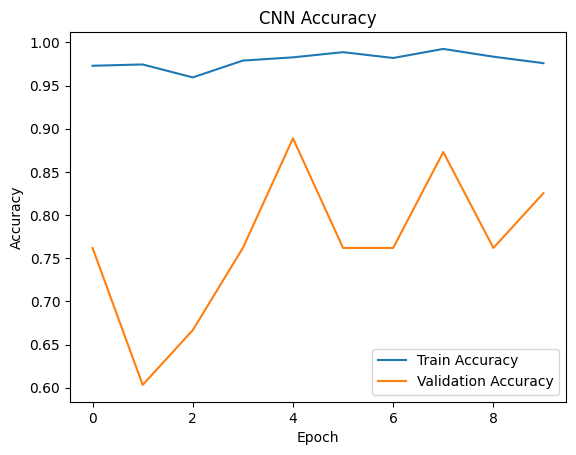

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()




5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 434ms/step
CNN Test Accuracy: 0.7961
CNN F1-score (Macro): 0.7879

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.78      0.87      0.82        52
     Powdery       0.77      0.94      0.85        50
        Rust       0.88      0.58      0.70        50

    accuracy                           0.80       152
   macro avg       0.81      0.80      0.79       152
weighted avg       0.81      0.80      0.79       152



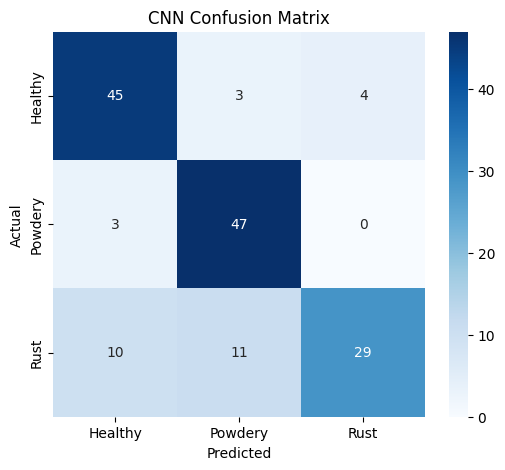

In [22]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(y_true, y_pred)
print(f"CNN Test Accuracy: {accuracy:.4f}")
f1_macro = f1_score(y_true, y_pred, average='macro')
print(f"CNN F1-score (Macro): {f1_macro:.4f}")
print("\nClassification Report:")

class_names = sorted(test_df['label'].unique())
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CNN Confusion Matrix')
plt.show()

In [31]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

def build_vgg16(input_shape=(128,128,3)):
    base = VGG16(weights="imagenet", include_top=False, input_shape=input_shape)
    for layer in base.layers:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.5)(x)
    output = Dense(3, activation="softmax")(x)

    model = Model(inputs=base.input, outputs=output)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

vgg_model = build_vgg16()
hist_vgg = vgg_model.fit(train_ds, validation_data=val_ds, epochs=15, verbose=1)


Epoch 1/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 179s 4s/step - accuracy: 0.4351 - loss: 1.1533 - val_accuracy: 0.6825 - val_loss: 0.8005
Epoch 2/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 201s 4s/step - accuracy: 0.6641 - loss: 0.7864 - val_accuracy: 0.7302 - val_loss: 0.6724
Epoch 3/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 175s 4s/step - accuracy: 0.7143 - loss: 0.6831 - val_accuracy: 0.7460 - val_loss: 0.5958
Epoch 4/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 174s 4s/step - accuracy: 0.7709 - loss: 0.5980 - val_accuracy: 0.7619 - val_loss: 0.5544
Epoch 5/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 177s 4s/step - accuracy: 0.7929 - loss: 0.5635 - val_accuracy: 0.7778 - val_loss: 0.5354
Epoch 6/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 179s 4s/step - accuracy: 0.7943 - loss: 0.5146 - val_accuracy: 0.7937 - val_loss: 0.5323
Epoch 7/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 172s 4s/step - accuracy: 0.7978 - loss: 0.4839 - val_accuracy: 0.8254 - val_loss: 0.5138
Epoch 8/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 204s 4s/step - accuracy: 0.8048 - loss: 0.4794 - val_accuracy: 0.8254 - v

In [34]:
from tensorflow.keras.applications import ResNet50

def build_resnet50(input_shape=(128,128,3)):
    base = ResNet50(weights="imagenet", include_top=False, input_shape=input_shape)
    for layer in base.layers:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.5)(x)
    output = Dense(3, activation="softmax")(x)

    model = Model(inputs=base.input, outputs=output)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

resnet_model = build_resnet50()
hist_resnet = resnet_model.fit(train_ds, validation_data=val_ds, epochs=10, verbose=1)


Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.3392 - loss: 1.1603 - val_accuracy: 0.3175 - val_loss: 1.0973
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.3718 - loss: 1.0985 - val_accuracy: 0.3651 - val_loss: 1.0907
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.3713 - loss: 1.0960 - val_accuracy: 0.3175 - val_loss: 1.0900
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.3604 - loss: 1.0874 - val_accuracy: 0.3651 - val_loss: 1.0864
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.3689 - loss: 1.0884 - val_accuracy: 0.3968 - val_loss: 1.0872
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.3931 - loss: 1.0812 - val_accuracy: 0.4127 - val_loss: 1.0842
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.3982 - loss: 1.0827 - val_accuracy: 0.4127 - val_loss: 1.0811
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.4116 - loss: 1.0750 - val_accuracy: 0.3810 - val_loss:

In [35]:
from tensorflow.keras.applications import MobileNetV2

def build_mobilenetv2(input_shape=(128,128,3)):
    base = MobileNetV2(weights="imagenet", include_top=False, input_shape=input_shape)
    for layer in base.layers:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.5)(x)
    output = Dense(3, activation="softmax")(x)

    model = Model(inputs=base.input, outputs=output)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

mobile_model = build_mobilenetv2()
hist_mobile = mobile_model.fit(train_ds, validation_data=val_ds, epochs=15, verbose=1)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 16s 276ms/step - accuracy: 0.7238 - loss: 0.6908 - val_accuracy: 1.0000 - val_loss: 0.0616
Epoch 2/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 209ms/step - accuracy: 0.9684 - loss: 0.1081 - val_accuracy: 0.9841 - val_loss: 0.0677
Epoch 3/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 205ms/step - accuracy: 0.9693 - loss: 0.0964 - val_accuracy: 0.9524 - val_loss: 0.1052
Epoch 4/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 219ms/step - accuracy: 0.9738 - loss: 0.0638 - val_accuracy: 0.9524 - val_loss: 0.1100
Epoch 5/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 221ms/step - accuracy: 0.9919 - loss: 0.0359 - val_accuracy: 0.9841 - val_loss: 0.0770
Epoch 6/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 230ms/step - accuracy: 0.9958 - loss: 0.0248 - val_accuracy: 0.9524 - val_loss: 0.1120
Epoch 7/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 203ms/step - accuracy: 0.9835 - loss: 0.0357 - val_accuracy: 0.9683 - val_loss: 0.0917
Epoch 8/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 11s 209ms/step 

In [39]:
models = {
    "VGG16": vgg_model,
    "ResNet50": resnet_model,
    "MobileNetV2": mobile_model
}

for name, model in models.items():
    loss, acc = model.evaluate(test_ds, verbose=0)
    print(f"{name}: Accuracy = {acc*100:.2f}%  |  Loss = {loss:.4f}")


VGG16: Accuracy = 79.61%  |  Loss = 0.4916
ResNet50: Accuracy = 44.74%  |  Loss = 1.0680
MobileNetV2: Accuracy = 95.39%  |  Loss = 0.2641


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


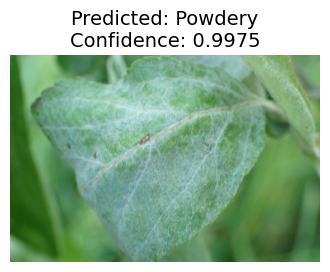

Predicted Class: Powdery | Confidence: 0.9975


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

def preprocess_image(img_path, img_size=(128,128)):
    img = Image.open(img_path).convert('RGB')
    img_resized = img.resize(img_size)
    img_array = np.array(img_resized, dtype='float32') / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array, img

def predict_and_show(img_path, model, class_names):
    img_array, original_img = preprocess_image(img_path)
    pred_probs = model.predict(img_array)
    pred_class = class_names[np.argmax(pred_probs)]
    confidence = np.max(pred_probs)


    plt.figure(figsize=(4,4))
    plt.imshow(original_img)
    plt.axis('off')
    plt.title(f"Predicted: {pred_class}\nConfidence: {confidence:.4f}", fontsize=14)
    plt.show()

    return pred_class, confidence

img_path = '/content/drive/MyDrive/archive (2)/Test/Test/Powdery/80bc7d353e163e85.jpg'
class_names = sorted(test_df['label'].unique())
pred_class, confidence = predict_and_show(img_path, model, class_names)
print(f"Predicted Class: {pred_class} | Confidence: {confidence:.4f}")

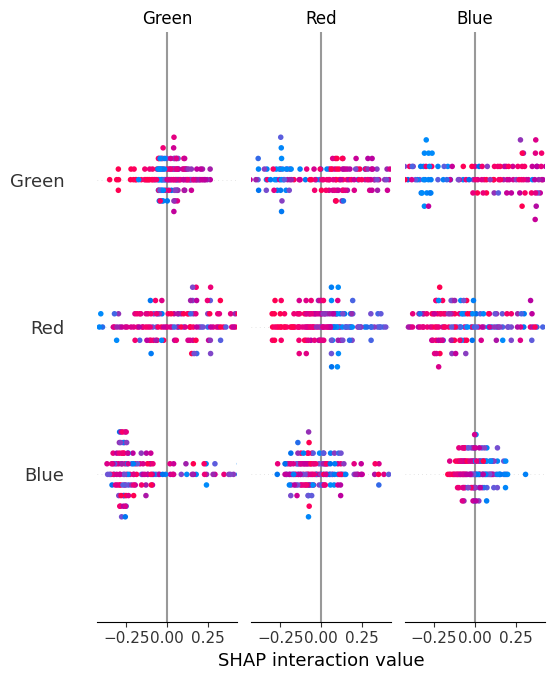

In [ ]:
import shap
from pdpbox import pdp
import matplotlib.pyplot as plt

explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test_rf)

shap.summary_plot(shap_values_rf, X_test_rf, feature_names=['Red', 'Green', 'Blue'])


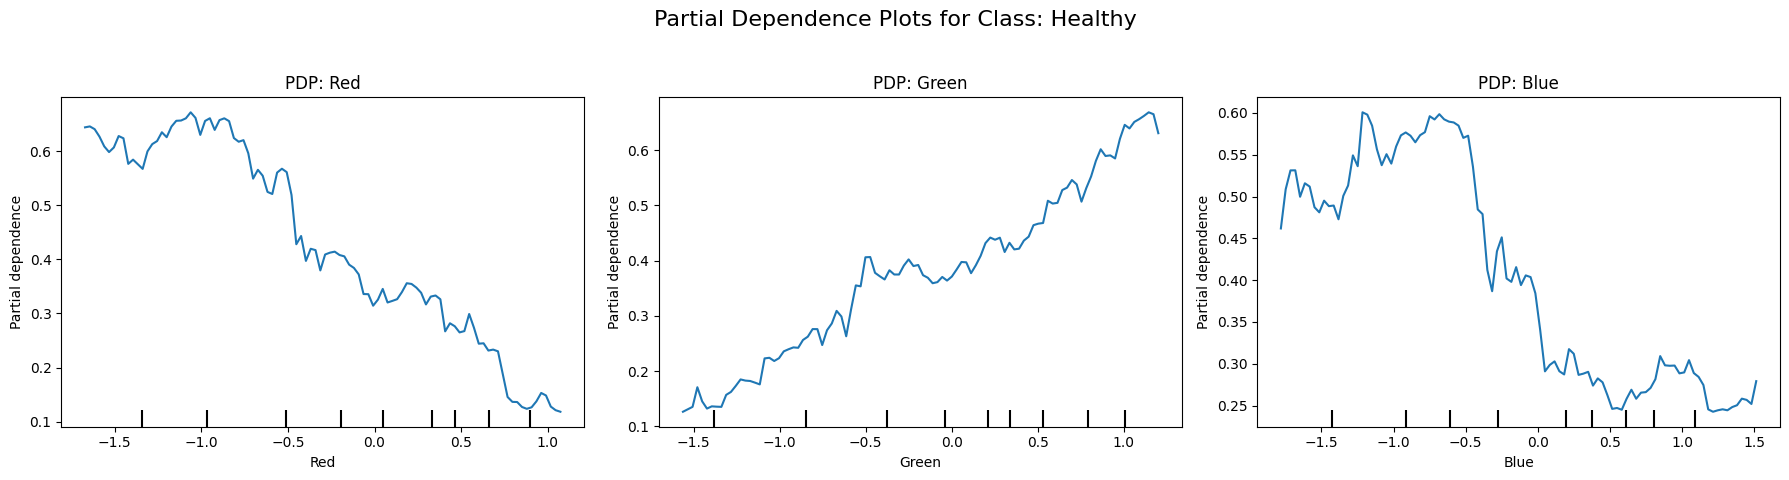

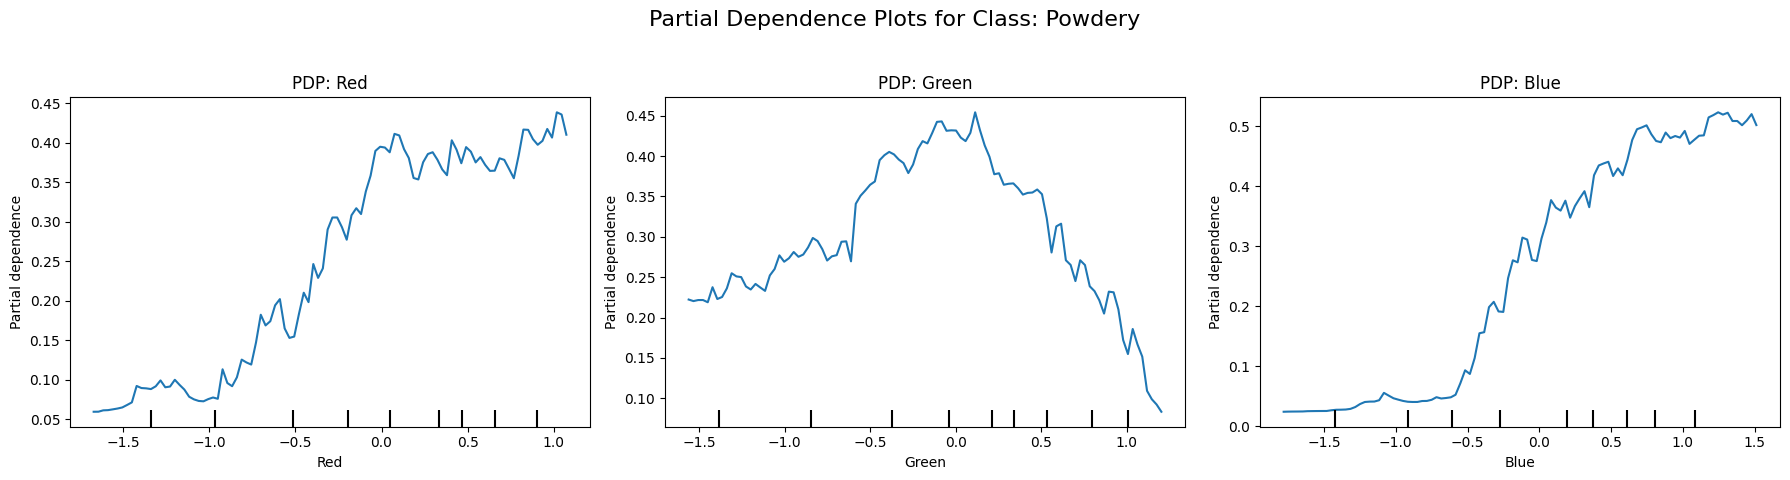

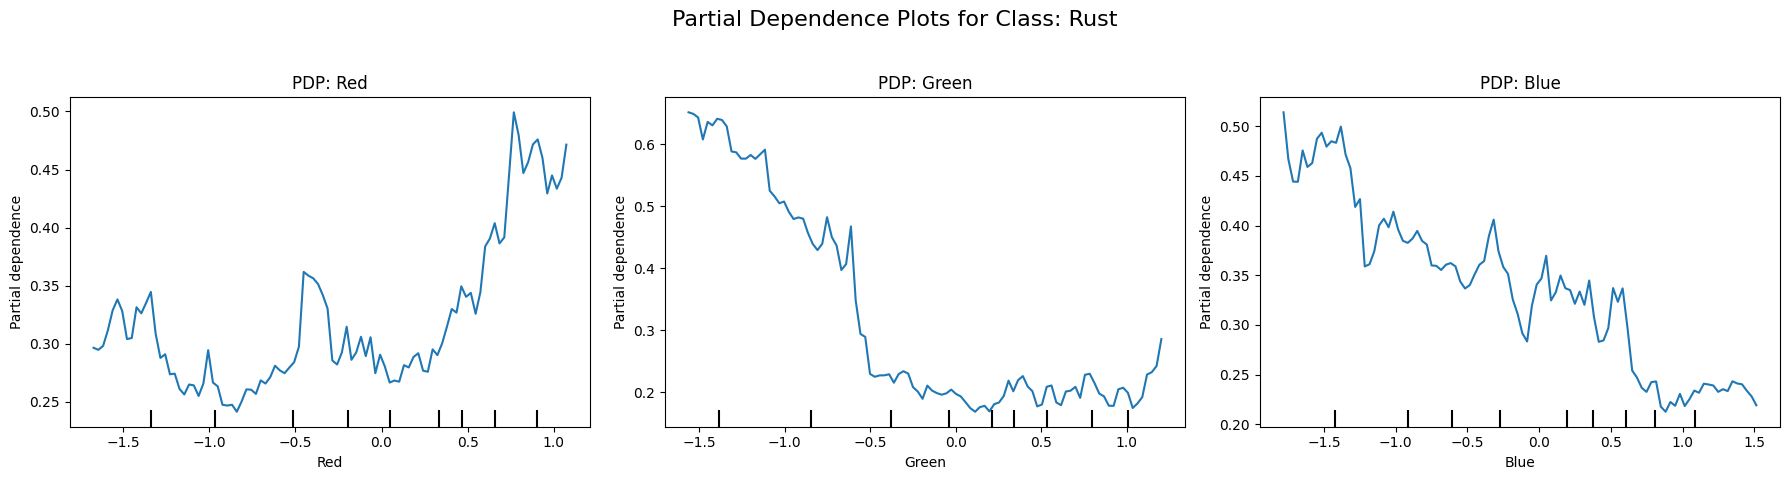

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

features = ['Red', 'Green', 'Blue']
class_names = sorted(le.classes_) # Get class names from the fitted LabelEncoder


for class_idx, class_name in enumerate(class_names):
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Partial Dependence Plots for Class: {class_name}", fontsize=16)

    for i, feature in enumerate(features):
        PartialDependenceDisplay.from_estimator(
            rf_model,
            X_test_rf,
            features=[i],
            feature_names=features,
            target=class_idx, # Specify the target class index
            ax=ax[i]
        )
        ax[i].set_title(f"PDP: {feature}")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

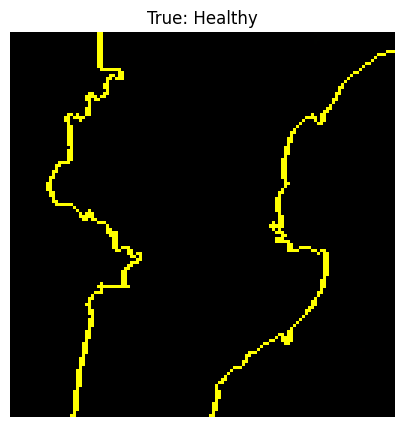

In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import numpy as np
import matplotlib.pyplot as plt


explainer = lime_image.LimeImageExplainer()


for x_batch, y_batch in test_ds.take(1):
    img = x_batch[0].numpy()
    true_label = y_batch[0].numpy()
    break


explanation = explainer.explain_instance(
    image=img,
    classifier_fn=lambda x: model.predict(x),
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

temp, mask = explanation.get_image_and_mask(
    label=true_label,
    positive_only=True,
    hide_rest=False
)


class_names = sorted(test_df['label'].unique())

plt.figure(figsize=(5,5))
plt.imshow(mark_boundaries(temp/255.0, mask))
plt.title(f"True: {class_names[true_label]}")
plt.axis('off')
plt.show()